<a href="https://colab.research.google.com/github/melatesfahum-web/-FUTURE_TrackCode_TaskNumber/blob/main/project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 550k/550k [00:00<00:00, 955kB/s]

Extracting files...


Data is loaded and df_prophet is defined!


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Forecast finished and saved to 'prophet_forecast_results.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

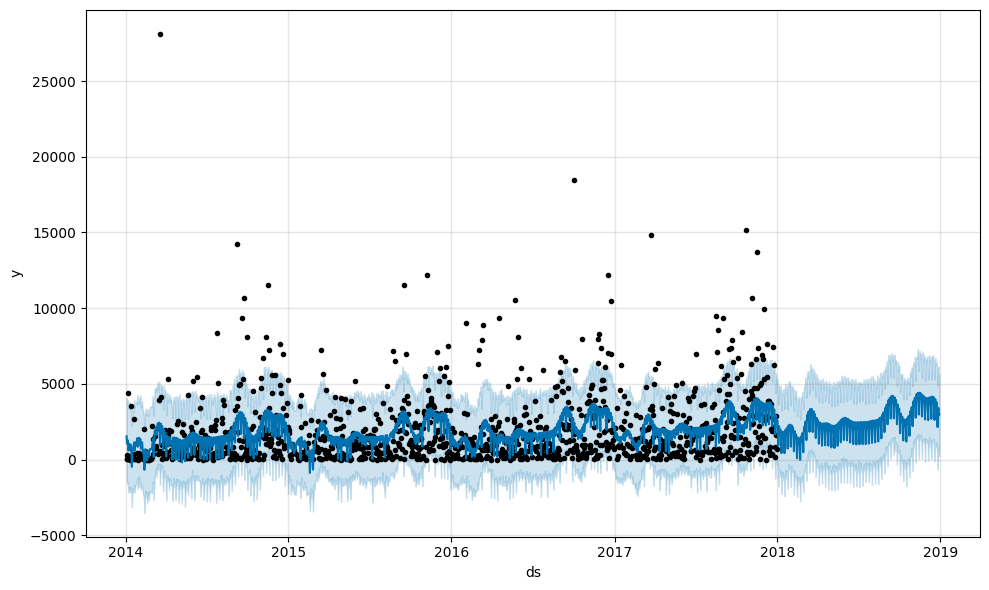

In [ ]:
!pip install kagglehub
import kagglehub
import pandas as pd
import os
from prophet import Prophet

# 1. Download dataset
path = kagglehub.dataset_download("vivek468/superstore-dataset-final")

# 2. Find the CSV file
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)

# 3. Load Data
df = pd.read_csv(full_path, encoding='windows-1252')

# 4. Define df_prophet (This fixes your NameError!)
df_prophet = df[['Order Date', 'Sales']].copy()
df_prophet.columns = ['ds', 'y']
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])
df_prophet = df_prophet.groupby('ds')['y'].sum().reset_index()

print("Data is loaded and df_prophet is defined!")
df_prophet.head()
# 1. Initialize and Fit
model = Prophet(yearly_seasonality=True, weekly_seasonality=True)
model.fit(df_prophet)

# 2. Create Future dates (1 year)
future = model.make_future_dataframe(periods=365)

# 3. Predict
forecast = model.predict(future)

# 4. Save to CSV (So you can download it for Power BI)
forecast.to_csv('prophet_forecast_results.csv', index=False)

# 5. Plot
model.plot(forecast)
print("Forecast finished and saved to 'prophet_forecast_results.csv'")
# This ensures the CSV is saved with the correct standard formatting
forecast.to_csv('clean_forecast.csv', index=False, encoding='utf-8')

from google.colab import files
files.download('clean_forecast.csv')

In [ ]:
# Save the forecast results with a clean structure
# ds = Date, yhat = Prediction, yhat_lower/upper = Confidence intervals
forecast.to_csv('clean_forecast.csv', index=False, encoding='utf-8')

# Download to your local computer
from google.colab import files
files.download('clean_forecast.csv')

NameError: name 'forecast' is not defined